#Q2. Unsupervised Learning

In [19]:
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import StandardScaler

# clustering
from sklearn.cluster import KMeans

# PCA
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

##1. Data Preparation

In [20]:
df = pd.read_csv("/content/sample_data/q2_customers.csv")

# display first rows
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [21]:
# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# convert back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

X_scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


#### Data Preparation

K-means clustering is a distance-based algorithm and depends on Euclidean distance.

Scaling is essential before K-means clustering because:
- Features with larger scales can dominate the distance calculation causing bias and incorrect results
- It ensures all features contribute equally to clustering as all features are on same scale
- It improves convergence and stability of the algorithm
- It allows the algorithm to find the center of clusters much faster by creating a more uniform mathematical space.

I used StandardScaler to normalize all features.

##2. Choosing K — Elbow Method

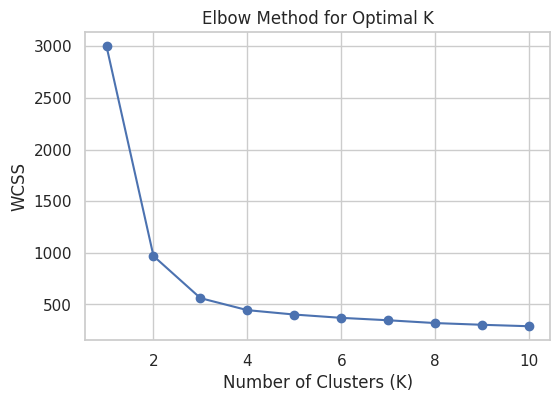

In [22]:
wcss = []

# compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# plot elbow graph
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

#### Optimal K

From the elbow plot, there is a sharp decrease in WCSS from K=1 to K=3 and after that the curve starts to flatten. This shows that increasing number of clusters beyond this point does not significantly reduce WCSS(graph becomes almost flat).

Optimal number of clusters is K=3

##3. K-Means Clustering

In [23]:
# fit K-means
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# add cluster column
df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [24]:
# convert centroids back to original scale
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(centroids, columns=df.columns[:-1])
centroid_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


#### Cluster Interpretation

- Cluster 0: Represents younger customers with low annual spend(approx 14k) but high visit frequency(approx 14 visits/month). These customers have low basket size and less no of categories purchased but shop frequently. They are frequent low-value shoppers.

- Cluster 1: Represents older, high value customers with very high annual spend(approx 89k) and large basket sizes(approx 5530). They visit less frequently(approx 2.5 visits/month) and have high days since last visit(aaprox 105) which means that they make infrequent but high-value purchases. These are premium or bulk buyers.

- Cluster 2: Represents middle-aged customers with moderate spending (approx 43k), moderate visit frequency(approx 8 visits/month) and have average basket sizes(aaprox 2021). These customers show balanced behavior and can be considered regular customers.

##4. Dimensionality Reduction with PCA

In [25]:
# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [26]:
# PCA loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


#### PCA Interpretation

- PC1 explains approximately 83.5% of the total variance which means it captures most of the information in the dataset. PC1 has strong positive contributions from features such as age,annual spend,basket size,days since last visit and number of categories purchased. It has a negative contribution from visits per month. I think PC1 captures overall customer value and purchasing power.

- PC2 explains about 5.5% of the variance and is dominated by the days since last visit feature. There are negative loadings in PC2 for age,annual spend, basket size, categories purchased, so these features vary inversely with the principal component. I think PC2 captures customer recency and engagement(behavioural) patterns.



##5. Cluster Visualisation

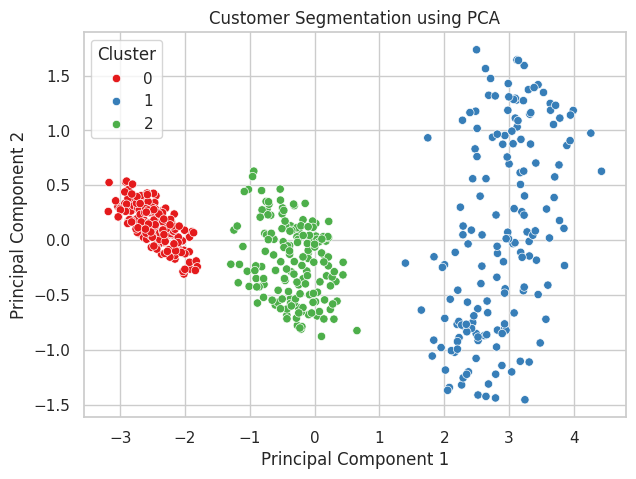

In [27]:
# create DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

# plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.show()